# Q1 — Salary Variation by Role, Industry, and Country

**Question:** How does salary vary by role, industry, and country?

## Setup

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


### Median salary by role

In [8]:
salary_by_role = (
    df.groupby("role_name")["salary_midpoint"]
    .agg(median_salary="median", mean_salary="mean", n="count")
    .sort_values("median_salary", ascending=False)
)
salary_by_role

,median_salary,mean_salary,n
role_name,,,
Data Scientist,"95,500.00","94,780.00",25
Data Architect,"75,500.00","63,666.67",3
Data Analyst,"53,000.00","55,297.90",381
Data Engineer,"53,000.00","65,750.00",38
Other,"53,000.00","60,494.32",88
Database Developer,"20,000.00","33,200.00",5


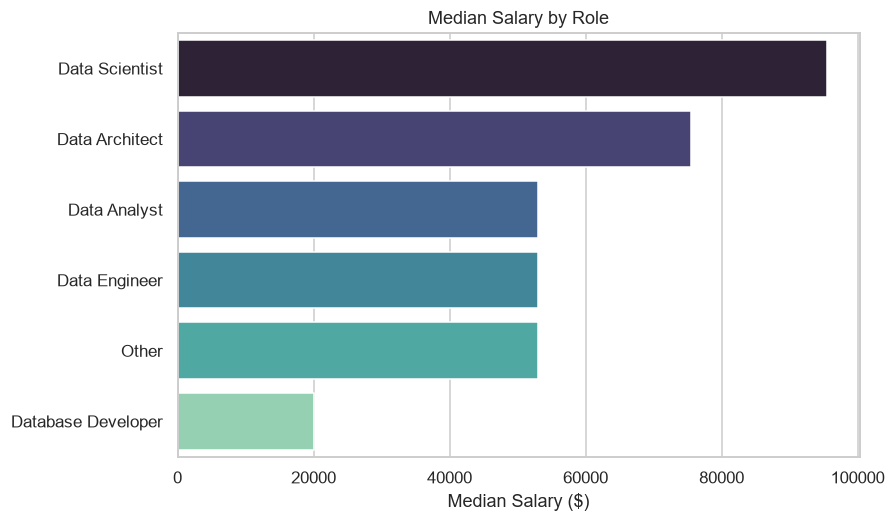

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
data = salary_by_role.reset_index()
sns.barplot(data=data, y="role_name", x="median_salary", ax=ax, hue="role_name", legend=False)
ax.set_title("Median Salary by Role")
ax.set_xlabel("Median Salary ($)")
ax.set_ylabel("")
fig.savefig(OUT / "q1_salary_by_role.png", bbox_inches="tight")
plt.show()

### Median salary by industry

In [10]:
salary_by_industry = (
    df.groupby("industry")["salary_midpoint"]
    .agg(median_salary="median", mean_salary="mean", n="count")
    .sort_values("median_salary", ascending=False)
)
salary_by_industry

,median_salary,mean_salary,n
industry,,,
Agriculture,"53,000.00","52,857.14",7
Construction,"53,000.00","48,892.86",14
Education,"53,000.00","55,039.47",38
Finance,"53,000.00","57,716.49",97
Healthcare,"53,000.00","64,184.52",84
Other,"53,000.00","53,875.61",205
Real Estate,"20,000.00","55,576.92",13
Tech,"20,000.00","48,130.00",150
Telecommunication,"20,000.00","40,295.45",22


### Median salary by country

In [11]:
salary_by_country = (
    df.groupby("country")["salary_midpoint"]
    .agg(median_salary="median", mean_salary="mean", n="count")
    .sort_values("median_salary", ascending=False)
)
salary_by_country

,median_salary,mean_salary,n
country,,,
United States,"75,500.00","79,007.66",261
Canada,"53,000.00","67,843.75",32
United Kingdom,"53,000.00","46,362.50",40
Rest of the world,"20,000.00","32,049.11",224
India,"20,000.00","29,910.96",73


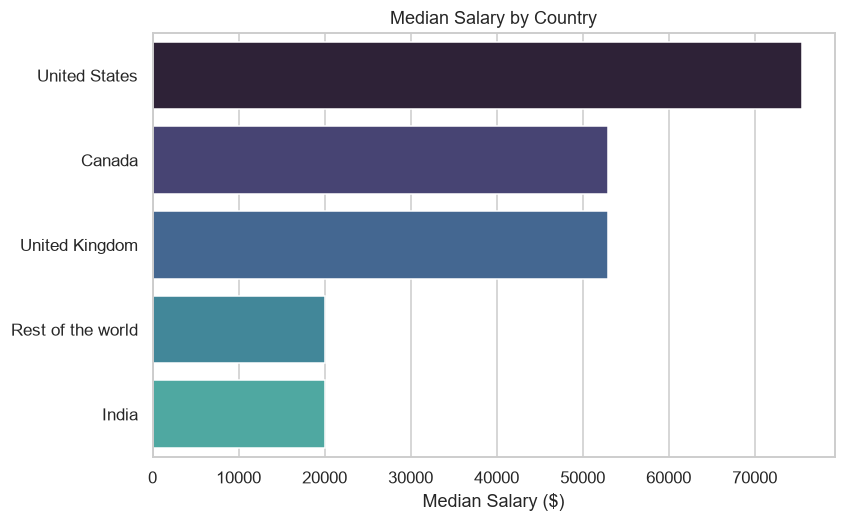

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
data = salary_by_country.reset_index()
sns.barplot(data=data, y="country", x="median_salary", ax=ax, hue="country", legend=False)
ax.set_title("Median Salary by Country")
ax.set_xlabel("Median Salary ($)")
ax.set_ylabel("")
fig.savefig(OUT / "q1_salary_by_country.png", bbox_inches="tight")
plt.show()

### Role x industry, combined (pivot heatmap)

In [13]:
pivot = pd.pivot_table(df, values="salary_midpoint", index="role_name",
                        columns="industry", aggfunc="median")
pivot

industry,Agriculture,Construction,Education,Finance,Healthcare,Other,Real Estate,Tech,Telecommunication
role_name,,,,,,,,,
Data Analyst,"53,000.00","53,000.00","75,500.00","53,000.00","53,000.00","53,000.00","64,250.00","20,000.00","20,000.00"
Data Architect,NaN,NaN,NaN,"20,000.00",NaN,"85,500.00",NaN,NaN,NaN
Data Engineer,NaN,"53,000.00","75,500.00","53,000.00","105,500.00","64,250.00","47,750.00","20,000.00",NaN
Data Scientist,NaN,NaN,"20,000.00","105,500.00","137,500.00","95,500.00","20,000.00","84,250.00","137,500.00"
Database Developer,NaN,NaN,"53,000.00",NaN,NaN,"53,000.00",NaN,"20,000.00","20,000.00"
Other,NaN,"20,000.00","53,000.00","75,500.00","53,000.00","53,000.00",NaN,"36,500.00","20,000.00"


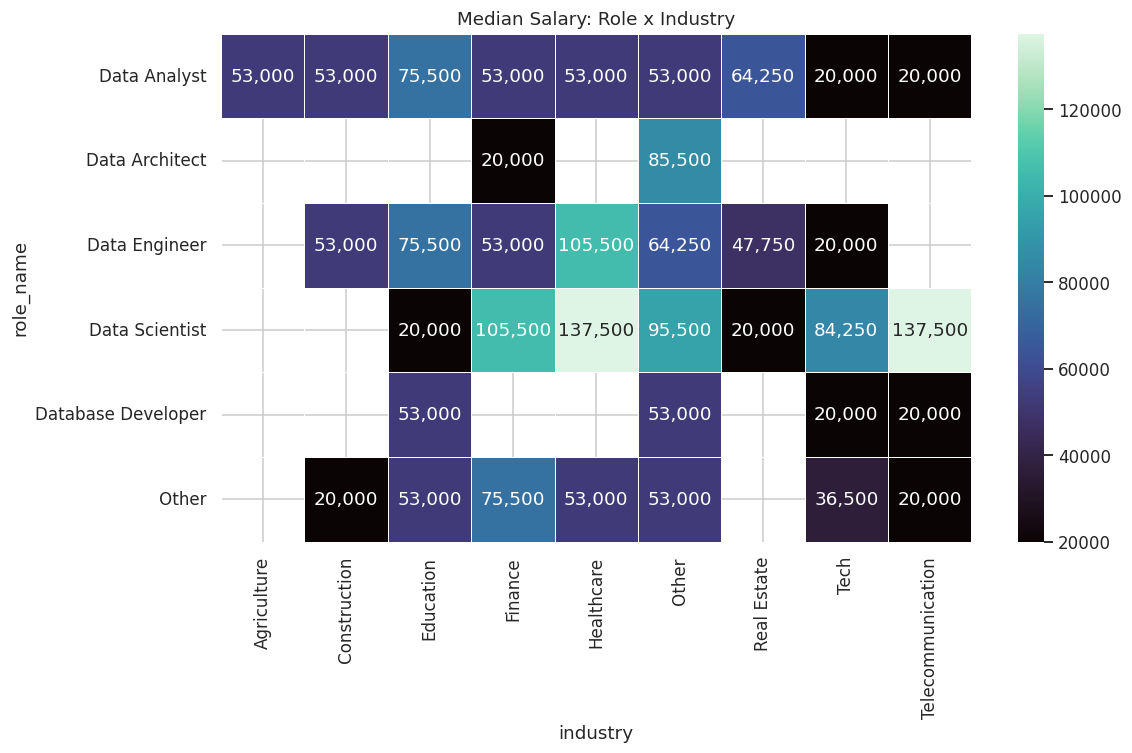

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(pivot, annot=True, fmt=",.0f", cmap="mako", linewidths=0.5, ax=ax)
ax.set_title("Median Salary: Role x Industry")
fig.savefig(OUT / "q1_salary_role_industry_heatmap.png", bbox_inches="tight")
plt.show()

**Takeaway:** Data Scientists lead by a wide margin (median ~$95.5K); the US pays noticeably more than the 'Rest of world' and India buckets.